In [22]:
%matplotlib ipympl

In [15]:
from functions import read_gro
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull


## Import data

In [2]:
# Read .gro data
data, title, num_atoms, box_dimensions = read_gro("./data/npt-HK4.gro")

# Dropping velocity components and setting index
data.drop(columns=["Vx", "Vy", "Vz"], inplace=True)  
data.set_index(['res_id', 'atom_name'], inplace=True) 

data

res_name  atom_id      x      y      z
res_id atom_name                                       
1      H28            HK4        1  1.602  0.962  0.912
       C48            HK4        2  1.565  0.879  0.852
       C47            HK4        3  1.655  0.809  0.773
       H27            HK4        4  1.754  0.855  0.756
       C46            HK4        5  1.603  0.717  0.683
...                   ...      ...    ...    ...    ...
1501   H23            HK4   126080  0.953  5.984  1.494
       C44            HK4   126081  0.736  6.009  1.525
       H24            HK4   126082  0.707  6.041  1.425
       C45            HK4   126083  0.632  5.988  1.615
       H25            HK4   126084  0.542  6.051  1.607

[126084 rows x 5 columns]

In [3]:
molecule = data.loc[10][["x", "y", "z"]].values

## Model molecule as 3d convex hull

The convex hull of a set of points is the smallest convex polygon (in 2D) or polyhedron (in 3D) that contains all the points in the set. 

It's like wrapping a rubber band (in 2D) or a tight sheet of material (in 3D) around the points. 

There are many algorithms available to compute the convex hull. We use the Quickhull algorithm from Scipy library.

https://en.wikipedia.org/wiki/Convex_hull_algorithms#Algorithms

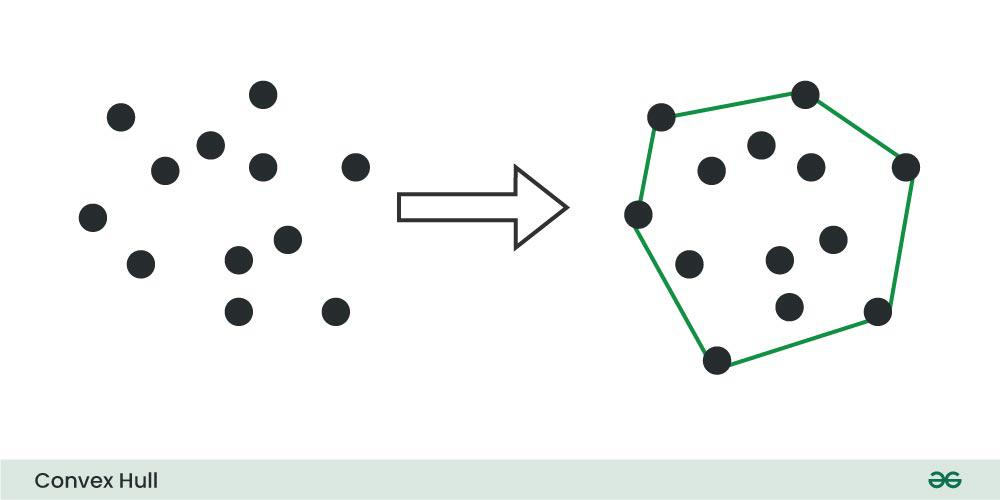
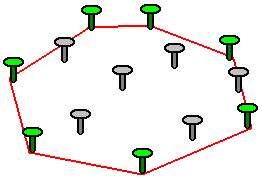
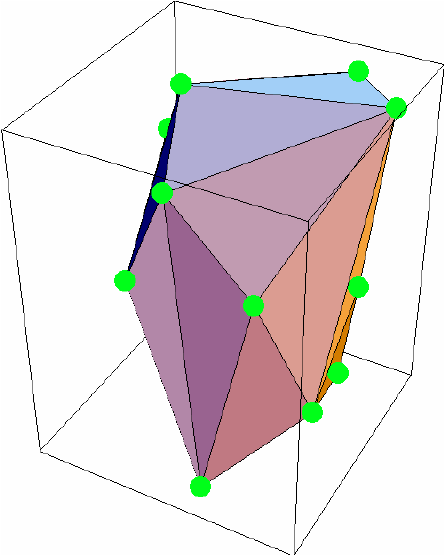


In [16]:
def molecule_convex_hull(points):
    """
    - Compute the convex hull of a molecule using the Quickhull algorithm.
    - Returns a scipy.spatial.ConvexHull object, which contains vertices, simplices (triangles), and volume.
    """
    if len(points) < 4:
        raise ValueError("At least 4 non-coplanar points are required for a 3D convex hull.")
    
    hull = ConvexHull(points, qhull_options='Qx')  # Qx avoids extra processing for degenerate cases
    return hull


In [9]:
hull = molecule_convex_hull(molecule)

print("Number of hull vertices:", len(hull.vertices))
print("Hull volume:", hull.volume)
print("Hull surface area:", hull.area)

# Hull vertices
print("Vertex coordinates:")
print(molecule[hull.vertices])

Number of hull vertices: 21
Hull volume: 0.6678942578333329
Hull surface area: 4.43841801042819
Vertex coordinates:
[[0.804 8.847 2.405]
 [0.863 9.076 2.041]
 [0.747 8.909 2.147]
 [0.934 9.491 1.87 ]
 [1.17  9.577 1.809]
 [1.365 9.43  1.878]
 [1.713 8.536 2.255]
 [1.464 8.521 2.208]
 [1.363 8.734 2.131]
 [1.871 8.628 2.436]
 [2.096 8.769 2.398]
 [2.208 8.972 2.481]
 [2.069 9.188 2.479]
 [1.897 9.366 2.551]
 [1.888 9.449 2.77 ]
 [1.811 9.489 3.049]
 [1.693 9.48  3.278]
 [1.563 9.282 3.334]
 [1.559 8.919 3.087]
 [1.323 8.851 3.11 ]
 [1.155 8.881 2.907]]


In [17]:
def plot_convex_hull(points, hull):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1, projection="3d")
    
    # Plot molecule points
    ax.scatter(points[:,0], points[:,1], points[:,2], color='blue', alpha=0.6)
    
    # Plot hull triangles
    for simplex in hull.simplices:
        tri = points[simplex]
        ax.add_collection3d(Poly3DCollection([tri], color='orange', alpha=0.3))
    
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()



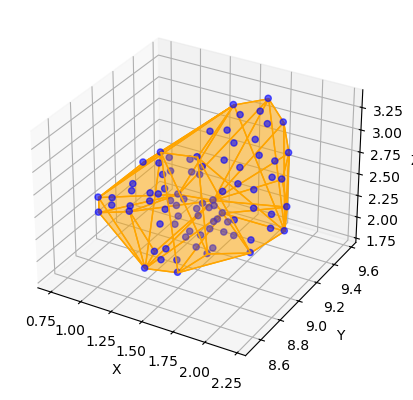

In [18]:
# Visualization
plot_convex_hull(molecule, hull)

## Animation visualization

In [19]:
# Animation

def hull_ani(points, hull, save = None):
    # Create figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Plot points
    ax.scatter(points[:,0], points[:,1], points[:,2], color="k", s=20)

    # Plot hull
    faces = [points[simplex] for simplex in hull.simplices]
    poly3d = Poly3DCollection(faces, alpha=0.3, facecolor="cyan", edgecolor="k")
    ax.add_collection3d(poly3d)

    # Set equal aspect ratio for the 3D axes
    ax.set_box_aspect([1,1,1])  

    # Animation: rotate the camera
    def rotate(angle):
        ax.view_init(elev=30, azim=angle)

    anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=100)

    plt.show()

    # Save as GIF
    if save != None:
        anim.save(f"./animation/{save}", writer="pillow", fps=20)


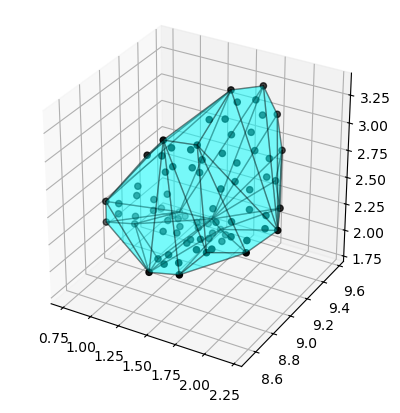

In [20]:
hull_ani(molecule, hull, save="convex_ani.gif")

## Model molecule as an Alpha Shape (3d-Concave Hull )

### Concave hull vs Alpha shape

Convex hull: smallest convex set containing all points.

Alpha shape: a tighter-fitting boundary that may follow cavities and indentations. It is a generalization of the concept of the convex hull.

### 𝛼 parameter

Large 𝛼 → smoother, closer to convex hull.

Small 𝛼 → more detail, possibly disconnected.

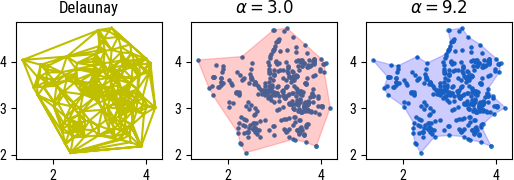
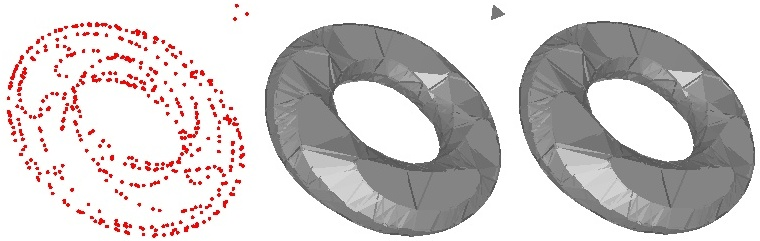

In [21]:
from scipy.spatial import Delaunay
from collections import Counter

def alpha_shape_3D(points, alpha):
    """
    - Compute the alpha shape (concave hull) of a set of 3D points.
    - Returns faces, the indices of points forming the hull surface triangles
    """
    if len(points) < 4:
        raise ValueError("Need at least 4 points for a 3D hull")
    
    tetra = Delaunay(points)
    faces = []

    for simplex in tetra.simplices:
        # Vertices of the tetrahedron
        pts = points[simplex]
        
        # Compute circumsphere radius
        A = np.hstack((2*(pts - pts[0]), np.ones((4,1))))
        b = np.sum(pts**2 - pts[0]**2, axis=1)
        try:
            x = np.linalg.lstsq(A, b, rcond=None)[0]
            center = x[:-1] + pts[0]
            r2 = np.sum((pts[0] - center)**2)
        except np.linalg.LinAlgError:
            continue
        
        if r2 < (1.0/alpha)**2:
            # Add boundary faces (each tetra has 4 faces)
            for i in range(4):
                face = tuple(sorted(simplex[np.arange(4) != i]))
                faces.append(face)
    
    # Remove internal faces (those appearing twice)
    face_count = Counter(faces)
    hull_faces = [f for f, c in face_count.items() if c == 1]
    
    return hull_faces

In [22]:
def plot_alpha_shape(points, faces, alpha):
    """
    Visualize 3D alpha shape with points and triangular surface.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Plot molecule points
    ax.scatter(points[:,0], points[:,1], points[:,2], color="blue", s=20, alpha=0.5)

    # Plot alpha shape surface
    mesh = Poly3DCollection([points[list(face)] for face in faces], alpha=0.3)
    mesh.set_facecolor("orange")
    ax.add_collection3d(mesh)

    ax.set_title(f"3D Alpha Shape (alpha={alpha})")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

### Finding the best alpha

In [23]:
for i in range(1,30):
    print("alpha: ", i/100, " Number of faces: ",len(alpha_shape_3D(molecule, i/100)))

alpha:  0.01  Number of faces:  38
alpha:  0.02  Number of faces:  42
alpha:  0.03  Number of faces:  42
alpha:  0.04  Number of faces:  42
alpha:  0.05  Number of faces:  42
alpha:  0.06  Number of faces:  42
alpha:  0.07  Number of faces:  42
alpha:  0.08  Number of faces:  42
alpha:  0.09  Number of faces:  44
alpha:  0.1  Number of faces:  84
alpha:  0.11  Number of faces:  80
alpha:  0.12  Number of faces:  20
alpha:  0.13  Number of faces:  8
alpha:  0.14  Number of faces:  8
alpha:  0.15  Number of faces:  0
alpha:  0.16  Number of faces:  0
alpha:  0.17  Number of faces:  0
alpha:  0.18  Number of faces:  0
alpha:  0.19  Number of faces:  0
alpha:  0.2  Number of faces:  0
alpha:  0.21  Number of faces:  0
alpha:  0.22  Number of faces:  0
alpha:  0.23  Number of faces:  0
alpha:  0.24  Number of faces:  0
alpha:  0.25  Number of faces:  0
alpha:  0.26  Number of faces:  0
alpha:  0.27  Number of faces:  0
alpha:  0.28  Number of faces:  0
alpha:  0.29  Number of faces:  0


### Visualize alpha shape

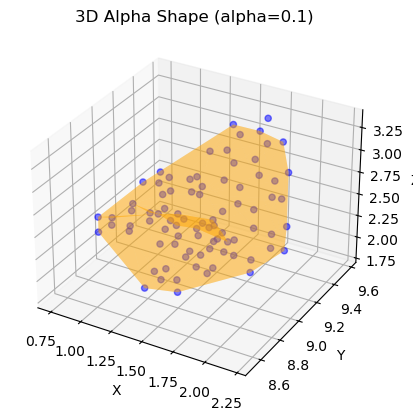

In [24]:
alpha = 0.1  # try adjusting this parameter
faces = alpha_shape_3D(molecule, alpha)
plot_alpha_shape(molecule, faces, alpha)

### Alpha shape animation

In [30]:
def alpha_ani(points, faces, save = None, writer="pillow"):
    # Create figure
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Plot points
    ax.scatter(points[:,0], points[:,1], points[:,2], color="k", s=20)

    # Plot hull
    faces_list = [points[list(face)] for face in faces]
    poly3d = Poly3DCollection(faces_list, alpha=0.3, facecolor="cyan", edgecolor="k")
    ax.add_collection3d(poly3d)

    # Set equal aspect ratio for the 3D axes
    ax.set_box_aspect([1,1,1])  

    # Animation: rotate the camera
    def rotate(angle):
        ax.view_init(elev=30, azim=angle)

    anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=100)

    plt.show()

    # Save as GIF
    if save != None:
        anim.save(f"./animation/{save}", writer, fps=20)


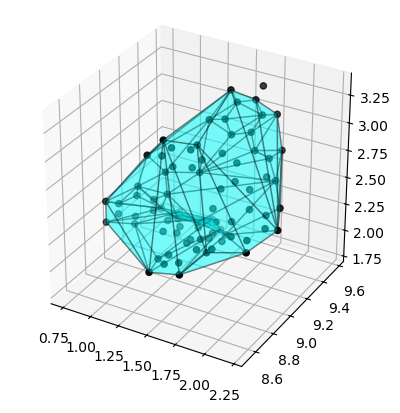

In [31]:
alpha_ani(molecule, faces, "alpha_ani.mp4", writer="ffmpeg")